# Алгоритмы на основе деревьев решений и их сравнение с ранее изученными алгоритмами

В данном примере разберем решение задачи регрессии с помощью следующих алгоритмов: 
* Линейная регрессия (без $L_1$- или $L_2$-регуляризации и с ними) 
* Метод k-ближайших соседей
* Решающее дерево
* Случайный лес 

Для всех алгоритмов при сравнении будем проводить подбор гиперпараметров.  

In [ ]:
# Уберем предупреждения, чтобы они не загромождали вывод

import warnings 
warnings.filterwarnings('ignore')

# 1. Чтение и предобработка данных

📌 **Задание 1** (*для всех вариантов*)

Загрузите набор данных из файла `CarPrice_Assignment.csv` и проведите следющую предобработку:
1. Удалите неинформативные столбцы
2. Определите, какие переменные являются категориальными, а какие числовыми, при необходимости измените тип переменной, чтобы он соответствовал ee содержательному смыслу и множеству возможных значений.
3. Создайти списки категориальных и числовых переменных (`categorical_cols` и `numerical_cols`)
4. Разделите столбец CarName на два: один должен содержать фирму-производителя, а второй - модель автомобиля.
5. При необходимости приведите названия моделей к единообразной лексике (например,  "Nissan" и "nissan" - это один и тот же производитель, поэтому преобразуйте эти слова к одному регистру).
6. Проверьте данные на пропуске. Если пропуски есть- удалите их или заполните.
7. Визуализируйте целевую переменную так, чтобы получить представление о ее распределении

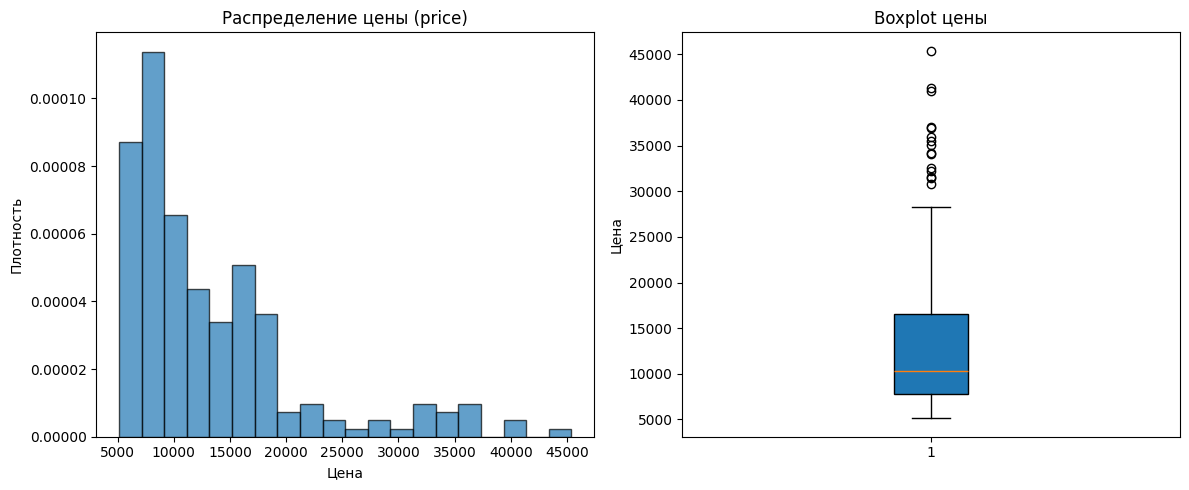

In [1]:
# Ваш код
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('CarPrice_Assignment.csv')
df = df.drop(columns=['car_ID'])

door_mapping = {'two': 2, 'four': 4}
df['doornumber'] = df['doornumber'].map(door_mapping)

cylinder_mapping = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
    
}
df['cylindernumber'] = df['cylindernumber'].map(cylinder_mapping)

numerical_cols = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
    'enginesize', 'boreratio', 'stroke', 'compressionratio',
    'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'doornumber', 'cylindernumber'
]

categorical_cols = [
    'fueltype', 'aspiration', 'carbody', 'drivewheel',
    'enginelocation', 'enginetype', 'fuelsystem'
]

df[['CarBrand', 'CarModel']] = df['CarName'].str.split(' ', n=1, expand=True)

df['CarBrand'] = df['CarBrand'].str.lower()

corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota'
}
df['CarBrand'] = df['CarBrand'].replace(corrections)


categorical_cols.append('CarBrand')

df = df.drop(columns=['CarName'])


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(df['price'], bins=20, density=True, alpha=0.7, edgecolor='black')
plt.title('Распределение цены (price)')
plt.xlabel('Цена')
plt.ylabel('Плотность')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'], vert=True, patch_artist=True)
plt.title('Boxplot цены')
plt.ylabel('Цена')

plt.tight_layout()
plt.show()

# 2. Подготовка данных к обучению моделей

Часть используемых моделей чувствительная к масштабу данных, поэтому для работы с моделями линейной регрессии и k ближайших соседей необходимо нормализовать числовые данные. Методы на основе деревьев решений (деревья решений, случайный лес) не требуют нормализации, поэтому их обучайте на исходной выборке.
Также среди предикторов имеются категориальные, которые необходимо закодировать (используйте `LabelEncoder` или  `OrdinalEncoder` из модуля `sklearn.preprocessing`, реазующие метод *LabelEncoding*).

Обратите внимание на **порядок проведения преобразования данных**:
- прежде всего данные необходимо разделить на обучаюшую и тестовую выборки;
- затем на обучающей выборке обучают как трансформеры масштабирования, так и кодировщики;
- применяют обученные трансформеры масштабирования и кодировщики к тестовой выборке.

❓ Почему нельзя сначала нормализовать и закодировать данные во всем наборе данных целиком, а затем уже делить на обучающую и тестовую выборки?

❓❓ Какие проблемы могут возникнуть при соблюдении правильного порядка преобразования данных?

📌 **Задание 2** (*для всех вариантов*): 
- разделите выборку на обучающю и тестовую;
- нормализуйте числовые предикторы модели;
- закодируйте категориальные предикторы методом *LabelEncoding*

In [2]:
# Ваш код
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
X = df[numerical_cols].drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_cat = df[categorical_cols].loc[X_train.index]
X_test_cat = df[categorical_cols].loc[X_test.index]
for col in categorical_cols:
    le = LabelEncoder()
    X_train_cat[col] = le.fit_transform(X_train_cat[col])
    X_test_cat[col] = le.transform(X_test_cat[col])

X_train = np.hstack((X_train_scaled, X_train_cat.values))
X_test = np.hstack((X_test_scaled, X_test_cat.values))

# 3. Линейная регрессия
### Модели с $L_1-$ и $L_2-$регуляризацией

В модели линейной регрессии предикторы должны быть линейно независимы. Однако в реальной жизни предикторы часто зависимы, причем часто наблюдается не попарная, а множественная зависимость, которую трудно диагностировать с помощью парных корреляций (такое явление называется **мультиколлинеарностью**). Проявлением эффекта мультиколлинеарости являются большие по модулю коэффициенты регрессии. Если не позволять коэффициентам регрессии принимать слишком большие значения, то качество прогноза линейной регрессии на данных с мультиколлинеарностью улучшится.

Для того, чтобы "штрафовать" модель за слишком большие коэффициенты $w$, применяют регуляризацию: в формулу регрессии добавляют еще одно слагаемое - норму вектора $w$. 

Пусть $\hat{y}$ — предсказания модели, $a$ — модель, $x = (x_1,... , x_d)$ — вектор признаков, $w = (w_1, ..., w_d)$ — вектор весов. Тогда:
* $L_1-$регуляризация:  
$$\hat{y} = a(x) = \sum_{i = 1}^{d}{w_ix_i+ \alpha ||w||_1}$$

* $L_2-$регуляризация:
$$\hat{y} = a(x) = \sum_{i = 1}^{d}{w_ix_i+ \alpha ||w||_2^2}$$

В Python модели линейной регрессии с регуляризацие можно обучить с помощью методов из модуля `sklearn.linear_model`:   
- объект `Lasso` - это модель линейной регрессии с регуляризацией $L_1$, 
- объект `Ridge` - модель с регуляризацией $L_2$.

📌 **Задание 3**
*выполняется по вариантам:*

**варианты 1-3:**
- обучите модель линейной регрессии, оцените ее качество на тестовой выборке с помощью метрик $MSE$ и $R^2$

**вариант 4:**
1. обучите модель линейной регрессии, оцените ее качество на тестовой выборке с помощью метрик $MSE$ и $R^2$
2. обучите модели линейной регрессии с $L_1$ и $L_2$ регуляризациями, оцените их качество на тестовой выборке.

In [3]:
# Ващ код
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#1
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
#2

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Lasso Mean Squared Error: {mse_lasso}')
print(f'Lasso R^2 Score: {r2_lasso}')

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Mean Squared Error: {mse_ridge}')
print(f'Ridge R^2 Score: {r2_ridge}')

Mean Squared Error: 11604280.190579496
R^2 Score: 0.8530062180609084
Lasso Mean Squared Error: 11594713.107621431
Lasso R^2 Score: 0.8531274062503553
Ridge Mean Squared Error: 11143476.049605416
Ridge R^2 Score: 0.858843318019074


# 4. Подбор гиперпараметров

Гиперпараметры играют важную роль в машинном обучении. Иногда бывает так, что гиперпараметры по умолчанию не позволяют модели обучаться, в то время как при определенной их комбинации качество модели значительно улучшается. 

Для подбора гиперпараметов моделей kNN, Desicion Tree и RandomForest в этой работе будем использовать простой перебор по сетке. Метод `GridSearchCV` из `sklearn.model_selection` организует подбор оптимальных гиперпараметров для модели путем перебора всех возможных комбинаций значений гиперпараметров. Подробнее о работе метода и о его аргументах см. документацию https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html.

Создадим пользовательскую функцию `gridsearch()`, которая будет на указанной выборке `(X_train, y_train)`, для модели `model` производить подбор параметров из словаря `params`, путем минимизации функции ошибок модели `scoring`.

In [4]:
from sklearn.model_selection import GridSearchCV

def gridsearch(X_train, y_train, model, params, scoring="neg_mean_squared_error", cv=5):
  searcher = GridSearchCV(
      model, 
      params,
      scoring=scoring,
      cv=cv
  )
  searcher.fit(X_train, y_train)
  best_params = searcher.best_params_

  print("Best hyperparameters:", best_params)
  return best_params

Приведем пример того, как можно использовать созданную нами функцию для подбора гиперпраметров модели линейной регресии 

In [5]:
X_train_new_scaled = X_train
best_params_lr = gridsearch(
    X_train_new_scaled, y_train,
    LinearRegression(),
    {
        "fit_intercept": [True, False], # default = True (Обучать ли свободный член w_0 или принять w_0=0)
        "positive": [True, False], # default = False (Принудительно все коэффициенты регрессии сделать положительными)
    }
)

Best hyperparameters: {'fit_intercept': False, 'positive': False}


В данном случае наилучшими получились гиперпараметры по умолчанию (для большинства задач с линейной регрессией будет так). 

Ниже приведем функцию для обучения и тестирования модели `model_train_test()`. Эта функция понадобится нам для дальнейших экспериментов.

In [6]:
def model_train_test(X_train, y_train, X_test, y_test, model):
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test, pred)
  r2 = r2_score(y_test, pred)
  print("MSE = {}; R2 = {}".format(round(mse, 3), round(r2, 3)))

  return pred, mse, r2

Испробуем эту функцию на модели линейной регрессии

In [7]:
X_test_new_scaled = X_test
pred_lr, mse_lr, r2_lr = model_train_test(
    X_train_new_scaled, 
    y_train, 
    X_test_new_scaled, 
    y_test, 
    LinearRegression(**best_params_lr)
)

MSE = 11944601.134; R2 = 0.849


📌 **Задание 4**

**только для варианта 4:**

С помощью определенных выше функций `gridsearch()` и `model_train_test()` для моделей Ridge и Lasso подберите значение гиперпараметра $\alpha$, определеющего размер штрафа за большие $||w||$. Какая из моделей линейной регрессии (с регуляризацией или без) оказалась более точной на тестовой выборке?

In [8]:
# Ващ код
best_params_ridge = gridsearch(
    X_train_new_scaled, y_train,
    Ridge(),
    {
        "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
        "fit_intercept": [True, False],
        "positive": [True, False],
    }
)
pred_ridge, mse_ridge, r2_ridge = model_train_test(X_train_new_scaled, y_train, X_test_new_scaled, y_test, Ridge(**best_params_ridge))
best_params_lasso = gridsearch(
    X_train_new_scaled, y_train,
    Lasso(),
    {
        "alpha": [0.01, 0.1, 1.0, 10.0, 100.0], 
        "fit_intercept": [True, False],
        "positive": [True, False],
    }
)
pred_lasso, mse_lasso, r2_lasso = model_train_test(X_train_new_scaled, y_train, X_test_new_scaled, y_test, Lasso(**best_params_lasso))


Best hyperparameters: {'alpha': 0.1, 'fit_intercept': False, 'positive': False}
MSE = 11882339.849; R2 = 0.849
Best hyperparameters: {'alpha': 10.0, 'fit_intercept': False, 'positive': False}
MSE = 11951745.019; R2 = 0.849


c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.275e+06, tolerance: 8.247e+05
  model = cd_fast.enet_coordinate_descent(
c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.086e+07, tolerance: 7.461e+05
  model = cd_fast.enet_coordinate_descent(
c:\Users\dpomi\source\repos\data_science\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

# 5. Метод k-ближайших соседей

Метод k ближайших соседей можно использовать не только в задаче классификации, но и в задаче регрессии. Предсказания модели выглядят на новом объекте будут вычисляться как среднее значение отклика на k соседях:

$$\hat{y} = a(x) = \frac{\sum_{k = 1}^K y_k}{K},$$ где $x$ — новый объект, для которого требуется построить прогноз, $K$ — число ближайших соседей, которых нужно рассматривать.

В Python модель регресии kNN задается классом `KNeighborsRegressor` из пакета `sklearn.neighbors`

📌 **Задание 5**

**для всех вариантов:**
- обучите модель регрессии kNN, реализуя с помощью определенной выше функции  `gridsearch()` подбор ее гиперпараметра "число ближайших соседей";
- определите качество прогноза получившейся модели на тестовой выборке. На экран должны быть выведены: 
    - оптимальное число ближайших соседей,
    - метрики $MSE$ и $R^2$, вычисленные на тестовой выборке.

In [9]:
# Ваш код
from sklearn.neighbors import KNeighborsRegressor
best_params_knn = gridsearch(
    X_train_new_scaled, y_train,
    KNeighborsRegressor(),
    {
        "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
        "weights": ['uniform', 'distance'],
        "p": [1, 2] 
    }
)
pred_knn, mse_knn, r2_knn = model_train_test(X_train_new_scaled, y_train, X_test_new_scaled, y_test, KNeighborsRegressor(**best_params_knn))
print(f'Optimal number of neighbors: {best_params_knn["n_neighbors"]}')
print(f'Mean Squared Error: {mse_knn}')
print(f'R^2 Score: {r2_knn}')

Best hyperparameters: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
MSE = 8343654.0; R2 = 0.894
Optimal number of neighbors: 5
Mean Squared Error: 8343653.999505041
R^2 Score: 0.8943092344862429


# 6. Решающие деревья
Структура решающего дерева представляет собой бинарное дерево с ответами в листьях и условиями в узлах. 

На практике в результате работы этих алгоритмов часто получаются слишком глубокие деревья, т. е. данная модель переобучается, поэтому рекомендуется контролировать и тщательно подбирать гиперпараметр "глубина дерева".

В Python модель решающего дерева реализована с помощью класса `DecisionTreeRegressor` из `sklearn.tree`, см. https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeRegressor.html

📌 **Задание 6**

**для всех вариантов:**
- обучите модель решающего дерева, реализуя с помощью определенной выше функции  `gridsearch()` подбор ее гиперпараметров "максимальная глубина дерева" и "минимальное число объектов в листе";
- определите качество прогноза получившейся модели на тестовой выборке. На экран должны быть выведены: 
    - оптимальные значения гиперпараметров,
    - метрики $MSE$ и $R^2$, вычисленные на тестовой выборке.

In [10]:
# Ваш код

from sklearn.tree import DecisionTreeRegressor
best_params_dt = gridsearch(
    X_train_new_scaled, y_train,
    DecisionTreeRegressor(),
    {
        #"max_depth": [None, 5, 10, 15, 20],
        "max_depth": [1, 5, 10, 15, 20],
        "min_samples_leaf": [1, 2, 4, 6, 8]
    }
)
pred_dt, mse_dt, r2_dt = model_train_test(X_train_new_scaled, y_train, X_test_new_scaled, y_test, DecisionTreeRegressor(**best_params_dt))
print(f'Optimal max depth: {best_params_dt["max_depth"]}, Optimal min samples leaf: {best_params_dt["min_samples_leaf"]}')
print(f'Mean Squared Error: {mse_dt}')
print(f'R^2 Score: {r2_dt}')

Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 2}
MSE = 7021900.488; R2 = 0.911
Optimal max depth: None, Optimal min samples leaf: 2
Mean Squared Error: 7021900.488108402
R^2 Score: 0.911052155567138


# 7. Ансамбли моделей на основе деревьев решений
В данном примере рассмотрим случайный лес, в основе которого лежит следующий принцип прогнозирования для решения задачи регрессии:

1. Одинаковые базовые модели обучаются на разных (независимых) подвыборках 

2. Прогноз на новом объекте получается усреднением прогнозов базовых моделей.

В Python модель случайного леса для задачи регрессии реалиется использованием класса `RandomForestRegressor` из `sklearn.ensemble`, см. https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestRegressor.html

📌 **Задание 7**

**для всех вариантов:**
- обучите модель случайного леса, реализуя с помощью определенной выше функции  `gridsearch()` подбор ее гиперпараметров "максимальная глубина дерева" и "число деревьев в ансамбле;
- определите качество прогноза получившейся модели на тестовой выборке. На экран должны быть выведены: 
    - оптимальные значения гиперпараметров,
    - метрики $MSE$ и $R^2$, вычисленные на тестовой выборке.

In [11]:
# Ваш код

from sklearn.ensemble import RandomForestRegressor
best_params_rf = gridsearch(
    X_train_new_scaled, y_train,
    RandomForestRegressor(),
    {
        "n_estimators": [50, 100, 200], 
        "max_depth": [1, 5, 10, 15, 20], 
    }
)
pred_rf, mse_rf, r2_rf = model_train_test(X_train_new_scaled, y_train, X_test_new_scaled, y_test, RandomForestRegressor(**best_params_rf))
print(f'Optimal n estimators: {best_params_rf["n_estimators"]}, Optimal max depth: {best_params_rf["max_depth"]}')
print(f'Mean Squared Error: {mse_rf}')
print(f'R^2 Score: {r2_rf}')

Best hyperparameters: {'max_depth': 15, 'n_estimators': 50}
MSE = 3219693.409; R2 = 0.959
Optimal n estimators: 50, Optimal max depth: 15
Mean Squared Error: 3219693.4094668753
R^2 Score: 0.9592154874607289


# 8. Подведение итогов

In [ ]:
# Код для вариантов 1-3
ans_df = pd.DataFrame()
ans_df["Model"] = ["Linear Regression", "kNN", "Decision Tree", "Random Forest"]
ans_df["MSE"] = [mse_lr,  mse_knn, mse_dt, mse_rf]
ans_df["R2"] = [r2_lr,  r2_knn, r2_dt, r2_rf]

In [12]:
# Код для варианта 4
ans_df = pd.DataFrame()
ans_df["Model"] = ["Linear Regression", "Ridge", "Lasso", "kNN", "Decision Tree", "Random Forest"]
ans_df["MSE"] = [mse_lr, mse_ridge, mse_lasso, mse_knn, mse_dt, mse_rf]
ans_df["R2"] = [r2_lr, r2_ridge, r2_lasso, r2_knn, r2_dt, r2_rf]

In [13]:
# код для все вариантов
ans_df.sort_values(by=["MSE"], ascending=True).sort_values(by=["R2"], ascending=False)

,Model,MSE,R2
5,Random Forest,3.219693e+06,0.959215
4,Decision Tree,7.021900e+06,0.911052
3,kNN,8.343654e+06,0.894309
1,Ridge,1.188234e+07,0.849484
0,Linear Regression,1.194460e+07,0.848695
2,Lasso,1.195175e+07,0.848605


📌 **Задание 8**

**для всех вариантов:**
Проанализируйте, какой алгоритм показал наилучшее качество на тестовой выборке. Отдельно обратите внимание:
- на результаты kNN - с чем может быть связано такое качество прогноза, какие есть способы улучшить результат?
- на сравнение результатов Random Forest и Desicion Tree.
    

# Бонус. Визуализация предсказаний 

Визуализация работы алгоритмов часто может помочь проанализировать качество их работы и причины потери точности на отдельных объектах. 

Так как предикторов в наших моделях много, мы не можем позволить себе визуализировать прогноз в системе координат "предикторы-прогноз", поэтому будем сравнивать точные значения отклика с прогнозными в системе координат "отклик - прогноз"

In [15]:
# Отсортируем значения целевой переменной и предсказания

order = np.argsort(y_test.values)
y_test_ordered = y_test.values[order]
pred_lr_ordered = pred_lr[order]

plt.rc('font', size=22) # далее во всех графиках будет использоваться такой же размер шрифта

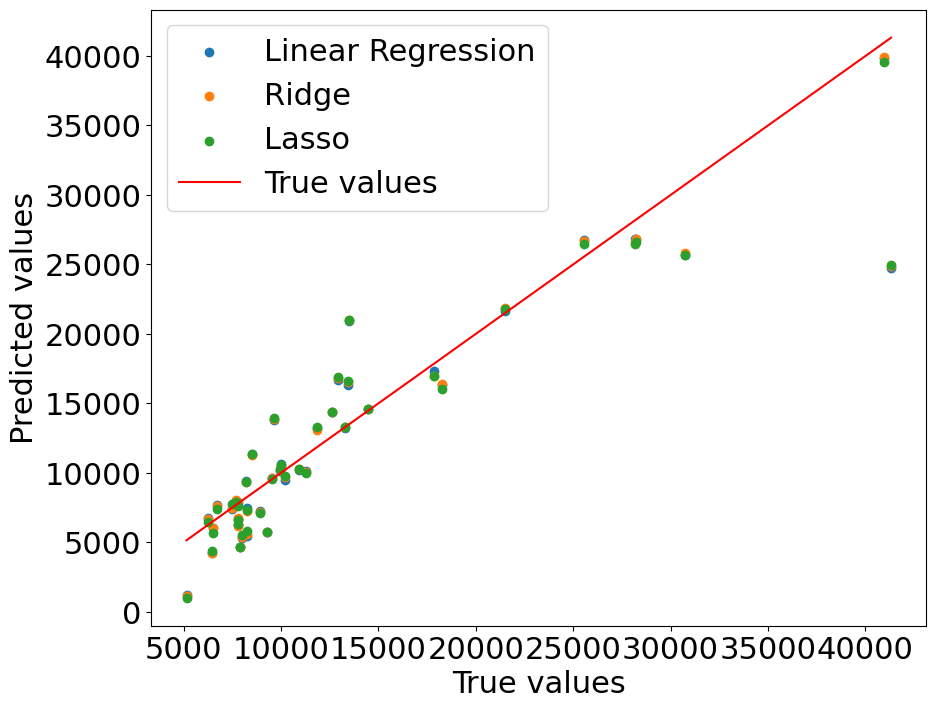

In [16]:
# Код для варианта 4
pred_ridge_ordered = pred_ridge[order]
pred_lasso_ordered = pred_lasso[order]

plt.figure(figsize=(10, 8))

plt.scatter(y_test_ordered, pred_lr_ordered, label="Linear Regression")
plt.scatter(y_test_ordered, pred_ridge_ordered, label="Ridge")
plt.scatter(y_test_ordered, pred_lasso_ordered, label="Lasso")

plt.plot(y_test_ordered, y_test_ordered, label="True values", color="red")
plt.legend();

plt.xlabel("True values");
plt.ylabel("Predicted values");

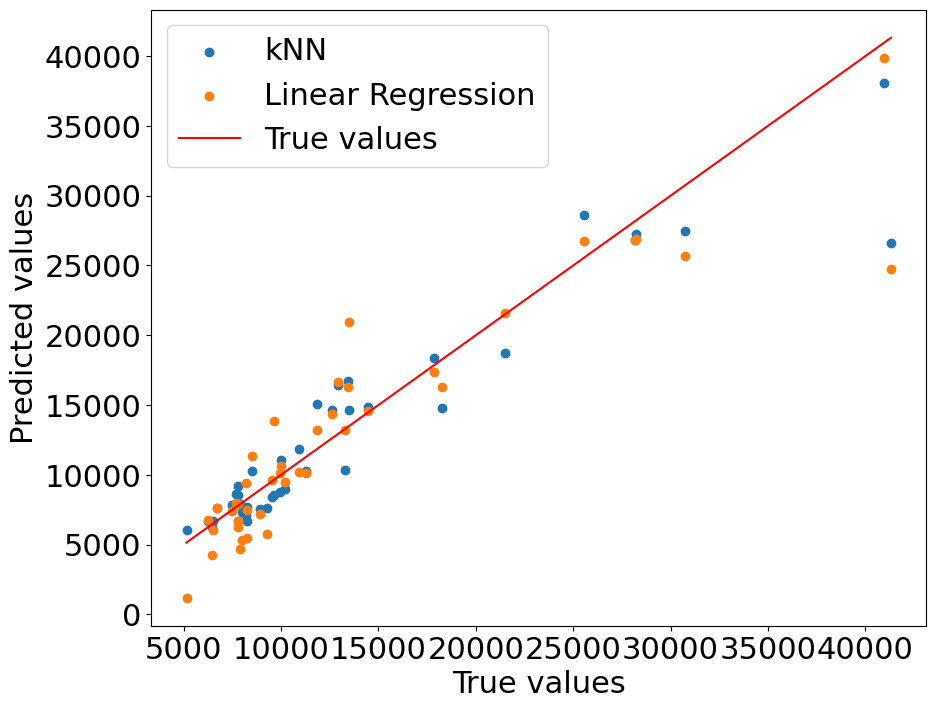

In [17]:
# Код для всех вариантов
plt.figure(figsize=(10, 8))

plt.scatter(y_test_ordered, pred_knn[order], label="kNN")
plt.scatter(y_test_ordered, pred_lr_ordered, label="Linear Regression")

plt.plot(y_test_ordered, y_test_ordered, label="True values", color="red")
plt.legend();

plt.xlabel("True values");
plt.ylabel("Predicted values");

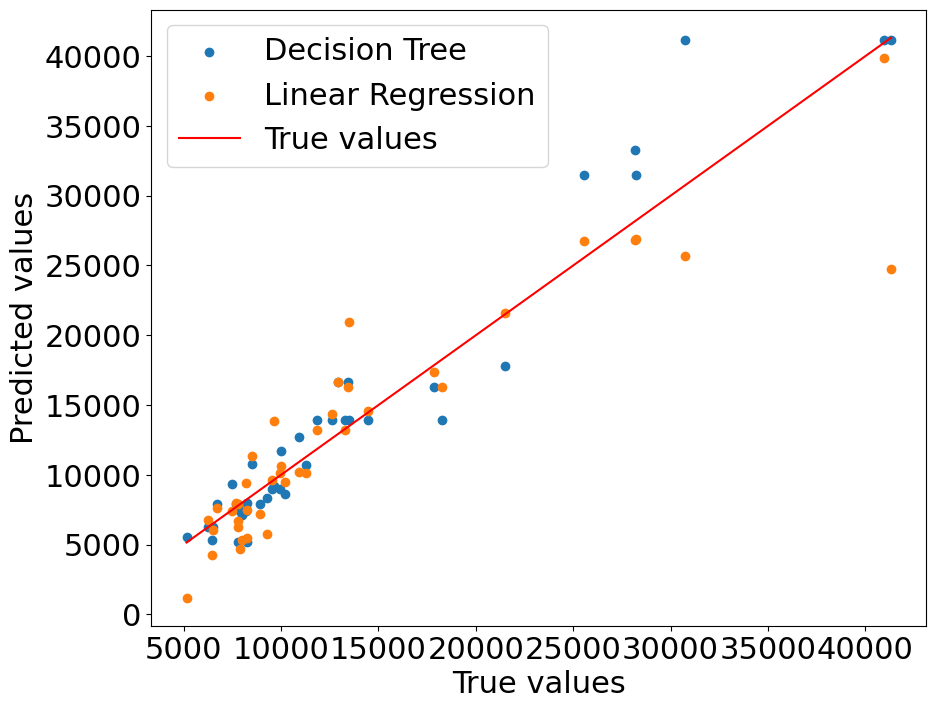

In [18]:
# Код для всех вариантов
plt.figure(figsize=(10, 8))

plt.scatter(y_test_ordered, pred_dt[order], label="Decision Tree")
plt.scatter(y_test_ordered, pred_lr_ordered, label="Linear Regression")

plt.plot(y_test_ordered, y_test_ordered, label="True values", color="red")
plt.legend();

plt.xlabel("True values");
plt.ylabel("Predicted values");

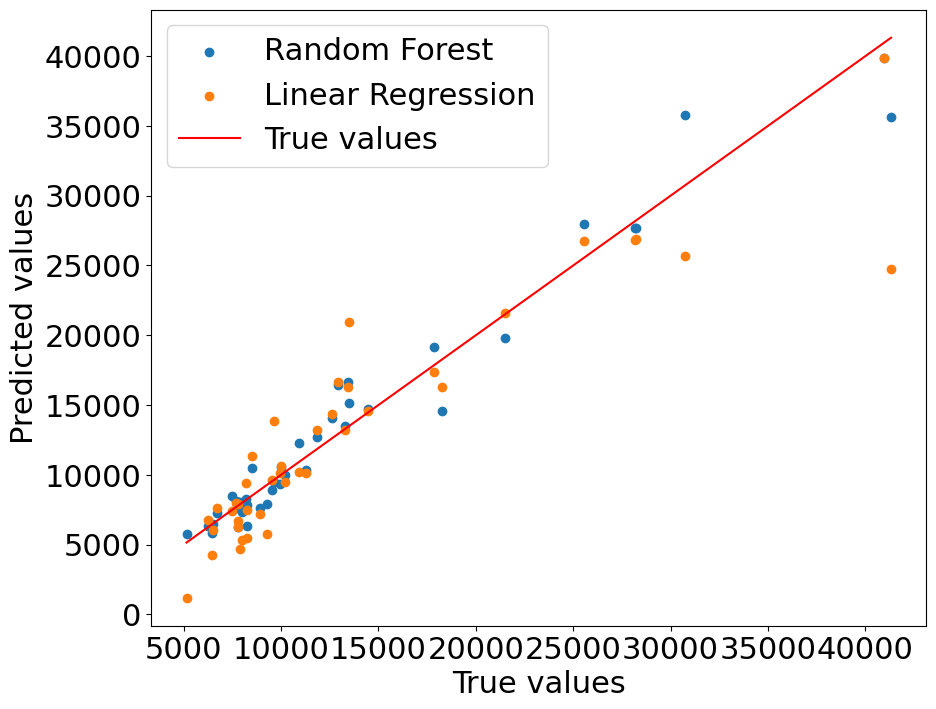

In [19]:
# Код для всех вариантов
plt.figure(figsize=(10, 8))

plt.scatter(y_test_ordered, pred_rf[order], label="Random Forest")
plt.scatter(y_test_ordered, pred_lr_ordered, label="Linear Regression")

plt.plot(y_test_ordered, y_test_ordered, label="True values", color="red")
plt.legend();

plt.xlabel("True values");
plt.ylabel("Predicted values");